In [3]:
pip install tqdm


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# ---- Imports ----
import os
import wfdb
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


In [2]:
import pandas as pd
import numpy as np
import wfdb
import ast

def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

path = '/Users/sumanthkamath/Documents/VS Code /BA878/Project/data/'
sampling_rate=100

# load and convert annotation data
Y = pd.read_csv('data/ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)

# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv('data/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass


In [3]:
Y.head()

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,diagnostic_superclass
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM]
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM]
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM]
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM]
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM]


In [7]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import roc_auc_score

# y_train and y_test are Series of lists like ['NORM'], ['MI', 'STTC'], etc.
mlb = MultiLabelBinarizer()
y_train_bin = mlb.fit_transform(y_train)
y_test_bin  = mlb.transform(y_test)

classes = mlb.classes_
num_classes = len(classes)
print("Classes:", classes)
print("Num classes:", num_classes)


Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']
Num classes: 5


In [ ]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, T, 12), y: (N, num_classes)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)  # multi-label → float for BCE

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ECGDataset(X_train, y_train_bin)
test_dataset  = ECGDataset(X_test,  y_test_bin)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)


In [9]:
class ECGTransformer(nn.Module):
    def __init__(self, input_dim=12, embed_dim=64, num_heads=4, num_layers=2, num_classes=5):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=128,
            dropout=0.1,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        # x: (B, T, C)
        x = self.input_proj(x)       # (B, T, E)
        x = x.permute(1, 0, 2)       # (T, B, E) for TransformerEncoder
        x = self.encoder(x)          # (T, B, E)
        x = x.permute(1, 2, 0)       # (B, E, T)
        logits = self.cls_head(x)    # (B, num_classes)
        return logits

device = "cuda" if torch.cuda.is_available() else "cpu"
model = ECGTransformer(
    input_dim=12,
    embed_dim=64,
    num_heads=4,
    num_layers=2,
    num_classes=num_classes   # from MultiLabelBinarizer
).to(device)

criterion = nn.BCEWithLogitsLoss()              # multi-label loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"Training on {device.upper()} with {num_classes} classes:", classes)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Training on CPU with 5 classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']


In [10]:
EPOCHS = 20  

loss_history = []
auc_history = []
label_acc_history = []
sample_acc_history = []

for epoch in range(1, EPOCHS + 1):
    # ---- TRAIN ----
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)             # (B, num_classes)
        loss = criterion(logits, y_batch)   # BCEWithLogitsLoss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)

    # ---- EVAL ON TEST (Macro AUC + Accuracies) ----
    model.eval()
    all_probs = []
    all_targets = []
    all_preds_binary = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            probs = torch.sigmoid(logits)   # convert logits → per-class probabilities

            all_probs.append(probs.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

            # threshold to get binary predictions (you can tune 0.5 → 0.3, etc.)
            preds_bin = (probs > 0.5).float()
            all_preds_binary.append(preds_bin.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    all_preds_binary = np.concatenate(all_preds_binary, axis=0)

    # ----- Macro AUC -----
    try:
        auc_macro = roc_auc_score(all_targets, all_probs, average="macro")
    except ValueError:
        # if some class is all 0 or all 1 in test set
        auc_macro = np.nan

    auc_history.append(auc_macro)

    # ----- Label-wise Accuracy (per label, averaged) -----
    label_accuracy = (all_preds_binary == all_targets).mean()
    label_acc_history.append(label_accuracy)

    # ----- Sample Accuracy (exact match: all labels correct for a sample) -----
    sample_accuracy = (all_preds_binary == all_targets).all(axis=1).mean()
    sample_acc_history.append(sample_accuracy)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Loss: {avg_loss:.4f} | "
        f"Macro AUC: {auc_macro:.4f} | "
        f"Label Acc: {label_accuracy:.4f} | "
        f"Sample Acc: {sample_accuracy:.4f}"
    )

print("✅ Training complete!")


Epoch 01/20 | Loss: 0.3946 | Macro AUC: 0.8659 | Label Acc: 0.8433 | Sample Acc: 0.4909
Epoch 02/20 | Loss: 0.3409 | Macro AUC: 0.8657 | Label Acc: 0.8339 | Sample Acc: 0.5064
Epoch 03/20 | Loss: 0.3278 | Macro AUC: 0.8787 | Label Acc: 0.8520 | Sample Acc: 0.5309
Epoch 04/20 | Loss: 0.3197 | Macro AUC: 0.8773 | Label Acc: 0.8408 | Sample Acc: 0.5068
Epoch 05/20 | Loss: 0.3151 | Macro AUC: 0.8823 | Label Acc: 0.8582 | Sample Acc: 0.5555
Epoch 06/20 | Loss: 0.3110 | Macro AUC: 0.8832 | Label Acc: 0.8583 | Sample Acc: 0.5564
Epoch 07/20 | Loss: 0.3065 | Macro AUC: 0.8869 | Label Acc: 0.8624 | Sample Acc: 0.5705
Epoch 08/20 | Loss: 0.3022 | Macro AUC: 0.8852 | Label Acc: 0.8589 | Sample Acc: 0.5537
Epoch 09/20 | Loss: 0.3005 | Macro AUC: 0.8864 | Label Acc: 0.8552 | Sample Acc: 0.5405
Epoch 10/20 | Loss: 0.2977 | Macro AUC: 0.8870 | Label Acc: 0.8598 | Sample Acc: 0.5519
Epoch 11/20 | Loss: 0.2947 | Macro AUC: 0.8890 | Label Acc: 0.8601 | Sample Acc: 0.5560
Epoch 12/20 | Loss: 0.2925 | Mac

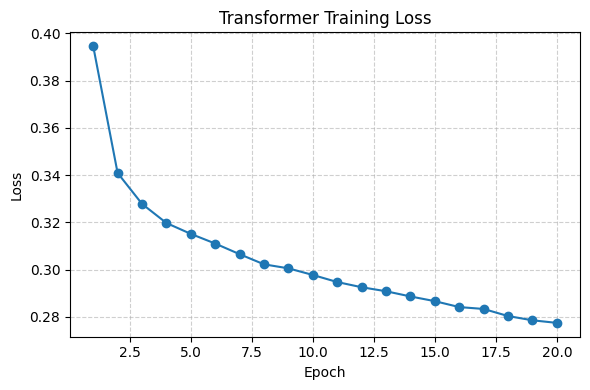

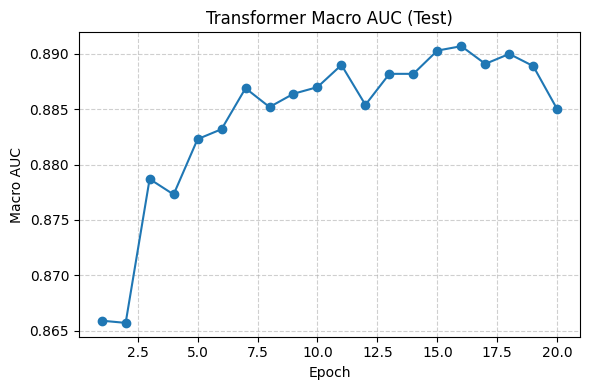

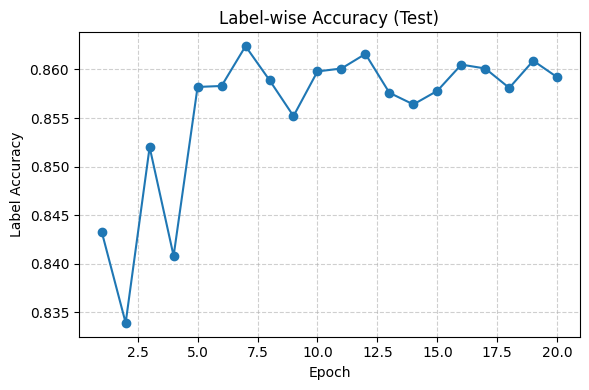

In [5]:
import matplotlib.pyplot as plt

# Reconstructed from your printed logs
loss_history = [
    0.3946, 0.3409, 0.3278, 0.3197, 0.3151,
    0.3110, 0.3065, 0.3022, 0.3005, 0.2977,
    0.2947, 0.2925, 0.2908, 0.2886, 0.2866,
    0.2841, 0.2833, 0.2803, 0.2785, 0.2774
]

auc_history = [
    0.8659, 0.8657, 0.8787, 0.8773, 0.8823,
    0.8832, 0.8869, 0.8852, 0.8864, 0.8870,
    0.8890, 0.8854, 0.8882, 0.8882, 0.8903,
    0.8907, 0.8891, 0.8900, 0.8889, 0.8850
]

label_acc_history = [
    0.8433, 0.8339, 0.8520, 0.8408, 0.8582,
    0.8583, 0.8624, 0.8589, 0.8552, 0.8598,
    0.8601, 0.8616, 0.8576, 0.8564, 0.8578,
    0.8605, 0.8601, 0.8581, 0.8609, 0.8592
]

epochs = range(1, len(loss_history) + 1)

# ---- Loss vs Epoch ----
plt.figure(figsize=(6,4))
plt.plot(epochs, loss_history, marker='o')
plt.title("Transformer Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---- Macro AUC vs Epoch ----
plt.figure(figsize=(6,4))
plt.plot(epochs, auc_history, marker='o')
plt.title("Transformer Macro AUC (Test)")
plt.xlabel("Epoch")
plt.ylabel("Macro AUC")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---- Label-wise Accuracy vs Epoch ----
plt.figure(figsize=(6,4))
plt.plot(epochs, label_acc_history, marker='o')
plt.title("Label-wise Accuracy (Test)")
plt.xlabel("Epoch")
plt.ylabel("Label Accuracy")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
